# ML & Modeling II: Building and Evaluating Models

Welcome! In this chapter we explore popular machine learning models and the tools used to build them.

---
### What We Will Cover
1. **Supervised Learning** — Decision Trees, Random Forests, XGBoost
2. **Unsupervised Learning** — K-Means Clustering
3. **Loss Functions** — MAE, MSE, RMSE
4. **Regularization** — Ridge and Lasso

> **Note:** All diagrams in this notebook are pre-rendered and display automatically — no need to run any cells to see them. The code cells at the end of each section let you try the concepts yourself.

---

## Setup

Run this cell once to load all the tools we need.

In [ ]:
# Run me first!
import numpy as np
from sklearn.datasets import make_classification, make_blobs, make_regression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings; warnings.filterwarnings('ignore')

print("Ready! You can now run other cells without issues!")

---
# Part 1: Supervised Learning Models

> **What is Supervised Learning?**
>
> You show the model many examples *where the correct answers are already labeled*,
> and it learns to predict answers for new examples it has never seen.
>
> **Everyday analogy:** A teacher shows students 1,000 photos of cats and dogs,
> labeling each one. After enough examples, students can identify cats and dogs in any new photo.

All three models in this section are based on the idea of **trees** — like a flowchart of yes/no questions.

---

## 1.1 Decision Tree 🌳

### Main Idea of Decision Tree:
A Decision Tree answers a question by asking a series of simple **yes/no questions**, one at a time — just like a flowchart you might draw on paper. You already think this way every morning!

<div align="center" style="margin:14px 0;">
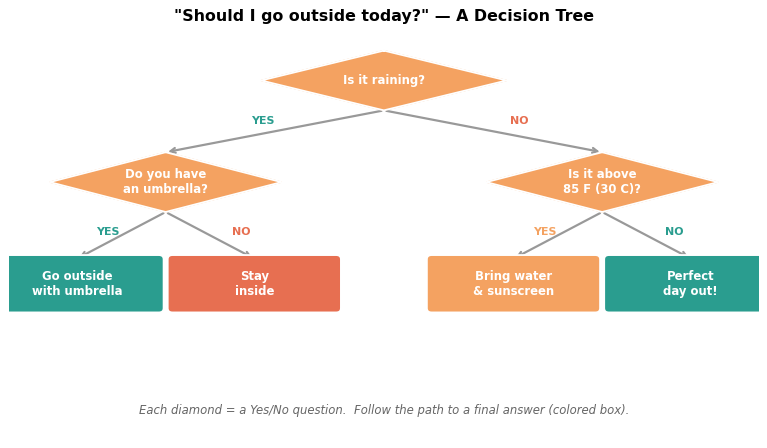
<p><em style="color:#777; font-size:0.9em;">Figure 1 — A decision tree for deciding whether to go outside. Follow the arrows based on yes/no answers.</em></p>
</div>

### Key Vocabulary

| Word | Plain-English Meaning |
|------|----------------------|
| **Root node** | The very first question at the top |
| **Branch** | One path after answering a question |
| **Leaf node** | A final answer — no more questions |
| **Depth** | How many questions are asked before reaching an answer |

### Pros & Cons

| Strengths | Weaknesses |
|-----------|------------|
| Easy to explain to anyone | Often **overfits** — memorizes training data instead of learning general rules |
| No special data prep needed | Small changes in data can create very different trees |
| Works with numbers and categories | Less accurate than more advanced models |

**Best used when:** You need to explain the model clearly, or as a quick starting point.

---

### Key Parameters — Decision Tree

| Parameter | What it does | Our value | Effect of changing it |
|-----------|-------------|-----------|----------------------|
| `max_depth` | Maximum number of yes/no questions the tree is allowed to ask | `3` | Higher = more complex tree, risk of overfitting; lower = simpler, may underfit |
| `random_state` | Fixes randomness so you get the same result every run | `42` | Any integer works — just keep it consistent |

> **Rule of thumb:** Start with `max_depth=3` or `4`. If accuracy is low, try increasing it by 1 at a time.

In [ ]:
# ── Helper: create weather data for this section ────────────────────────────
def making_data_for_decision_tree():
    """
    Returns weather data for predicting rain (1 = rain, 0 = no rain).
    Features: temperature, humidity, cloud cover, wind speed (300 days).
    """
    X, y = make_classification(
        n_samples=300,   # number of examples (days of weather data)
        n_features=4,    # total number of features (weather measurements)
        n_informative=3, # how many features actually contain useful signal
        n_redundant=1,   # features that are just combinations of informative ones
        random_state=42  # fixes the randomness — same data every run
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,   # 30% of data held back for testing, 70% used for training
        random_state=42
    )
    return X_train, X_test, y_train, y_test

# Call it and train a Decision Tree
X_train, X_test, y_train, y_test = making_data_for_decision_tree()

tree = DecisionTreeClassifier(
    max_depth=3,     # tree can ask at most 3 yes/no questions before giving an answer
    random_state=42  # makes results reproducible
)
tree.fit(X_train, y_train)   # "fit" = learn patterns from training data

acc = tree.score(X_test, y_test)  # test on data the tree has NEVER seen before
print(f"Decision Tree correctly predicted rain: {acc:.1%} of the time")

---
## 1.2 Random Forest 🌲🌲🌲

### Main Idea of Random Forest:
A single Decision Tree can be unreliable — maybe it happened to see unlucky training examples.
A **Random Forest** solves this by building *many* trees and having them **vote** on the answer together.

**Everyday analogy:** Instead of asking *one* friend whether to bring an umbrella,
you ask **100 friends**. Even if a few get it wrong, the majority will get it right.

Each tree in the forest:
- Is trained on a **random sample** of the data (so each tree sees slightly different examples)
- Only looks at a **random subset of features** at each split (so the trees disagree in useful ways)

The variety means trees make *different* mistakes — and those mistakes cancel each other out.

<div align="center" style="margin:14px 0;">
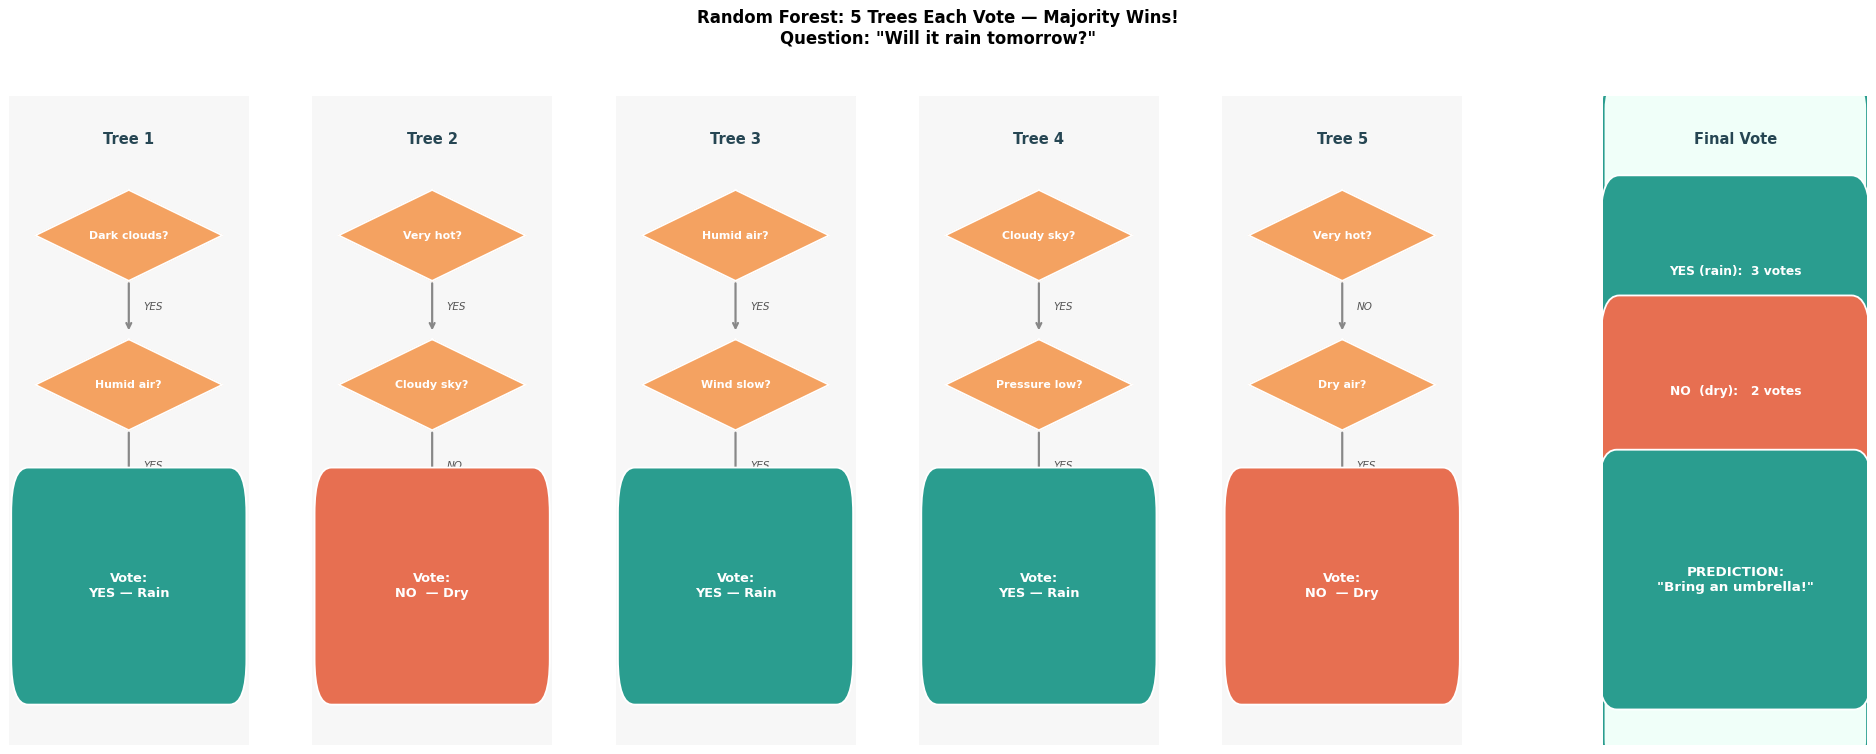
<p><em style="color:#777; font-size:0.9em;">Figure 2 — Five trees each look at different clues and vote. Three say YES, two say NO, so the final answer is YES.</em></p>
</div>

### Pros & Cons

| Strengths | Weaknesses |
|-----------|------------|
| Much more accurate than a single tree | Hard to visualize or explain (100 trees!) |
| Resistant to overfitting | Slower to train than a single tree |
| Works well without much tuning | Uses more memory |

**Best used when:** You want solid accuracy with minimal effort — this is the go-to default for many problems.

---

### Key Parameters — Random Forest

| Parameter | What it does | Our value | Effect of changing it |
|-----------|-------------|-----------|----------------------|
| `n_estimators` | How many trees to build and vote with | `100` | More trees = more stable, but slower to train. Usually 100–500 is enough |
| `max_depth` | Max questions per tree (same as Decision Tree) | not set | If unset, trees grow until pure — often fine for Random Forest |
| `random_state` | Fixes randomness for reproducibility | `42` | Any integer works |

> **Why does more trees help?** Each tree sees slightly different data and features, so they make different mistakes. When 100 trees vote together, individual errors cancel out — the majority is usually right.

In [ ]:
# Reuse the same weather data from the Decision Tree section
X_train, X_test, y_train, y_test = making_data_for_decision_tree()

forest = RandomForestClassifier(
    n_estimators=100,  # build 100 separate trees and have them vote together
    random_state=42    # fixes randomness — same forest every run
)
forest.fit(X_train, y_train)   # train all 100 trees at once

print(f"Decision Tree accuracy: {tree.score(X_test, y_test):.1%}")
print(f"Random Forest accuracy: {forest.score(X_test, y_test):.1%}")
print()
print("The Random Forest is more reliable — 100 trees voted together!")

---
## 1.3 XGBoost ⚡️

### Main Idea of XGBoost:
XGBoost also builds many trees — but with a completely different strategy.
Instead of building trees **independently** (like Random Forest), XGBoost builds them
**one at a time, sequentially**, where each new tree **specifically corrects the mistakes** of all previous trees.

**Everyday analogy:** Think about learning to parallel park a car:
- **Attempt 1:** You park too far left. *(mistake noted: go right next time)*
- **Attempt 2:** You over-correct and go too far right. *(mistake noted: go left a bit)*
- **Attempt 3:** Almost perfect! *(tiny adjustment needed)*
- Each attempt fixes the specific problem from the attempt before.

XGBoost learns the exact same way.

---

### Sequential vs. Parallel — The Key Difference

This is one of the most important distinctions in all of machine learning:

| | Random Forest | XGBoost |
|---|---|---|
| **How trees are built** | All at the same time (in parallel) | One at a time, in strict order (sequentially) |
| **Can Tree 2 start before Tree 1 finishes?** | Yes — they are independent | No — Tree 2 *needs* Tree 1's errors first |
| **What each tree learns** | The original data labels | The *errors* left by all previous trees |
| **Effect** | Average of independent opinions | Progressively refined, error-correcting prediction |
| **Training speed** | Faster — trees run in parallel | Slower — must go one by one |

> **Why does sequential matter?**
> Because each tree has a specific job: fix what the last tree got wrong.
> Tree 2 cannot do its job without knowing Tree 1's mistakes — so the order is essential.
> This focused, step-by-step correction is exactly why XGBoost tends to be more accurate.

<div align="center" style="margin:14px 0;">
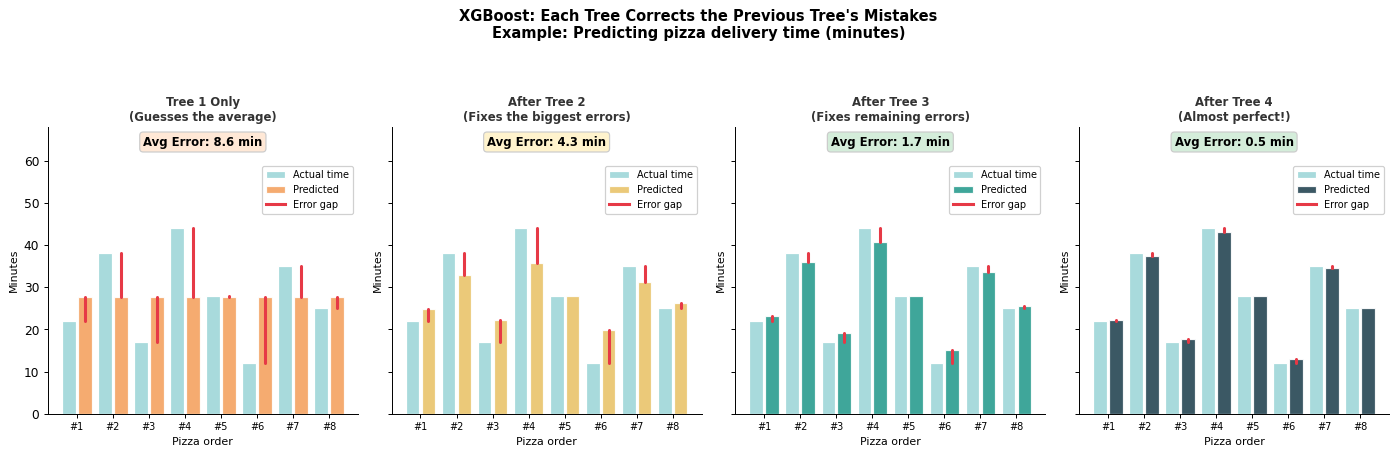
<p><em style="color:#777; font-size:0.9em;">Figure 3 — Each new tree corrects the remaining errors. The average error shrinks with every tree added.</em></p>
</div>

### Why does XGBoost win on harder problems?

Because sequential learning is *smarter* than parallel voting: instead of each tree ignoring the others,
every tree has one job — fix what went wrong before. Random Forest's trees are diverse but uncoordinated;
XGBoost's trees are coordinated and purposeful. That focused, step-by-step correction adds up to
better accuracy, especially on complex datasets with many noisy features.

<div align="center" style="margin:14px 0;">
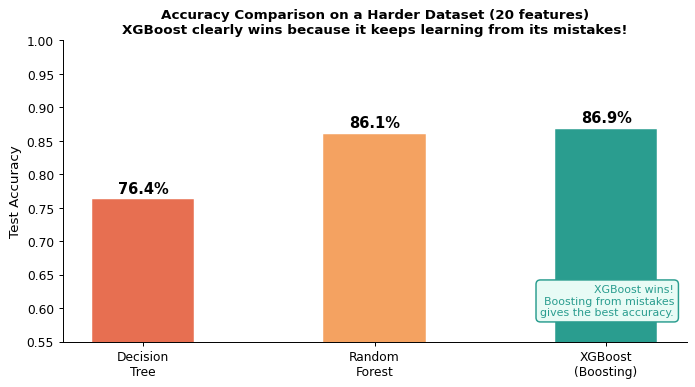
<p><em style="color:#777; font-size:0.9em;">Figure 4 — On a harder 20-feature dataset, XGBoost clearly outperforms Random Forest, which outperforms a single Decision Tree.</em></p>
</div>

### Pros & Cons

| Strengths | Weaknesses |
|-----------|------------|
| State-of-the-art accuracy on real-world data | More settings to tune (learning rate, depth, etc.) |
| Built-in protection against overfitting | Slower to train on very large datasets |
| Wins most data science competitions | Harder to interpret than a single tree |

**Best used when:** You need the highest possible accuracy on tabular (spreadsheet-style) data.

---

### Key Parameters — XGBoost (`GradientBoostingClassifier`)

| Parameter | What it does | Our value | Effect of changing it |
|-----------|-------------|-----------|----------------------|
| `n_estimators` | Total number of trees to build sequentially | `100` | More = better accuracy up to a point, but slower and risks overfitting |
| `learning_rate` | How much each new tree is allowed to correct the previous error | `0.1` | Lower = more careful learning, needs more trees; higher = learns fast, risks overshooting |
| `max_depth` | How deep each individual correction tree can grow | `4` | Deeper = each tree captures more complex patterns; too deep risks overfitting |
| `random_state` | Reproducibility | `42` | Any integer |

> **learning_rate vs n_estimators trade-off:** Think of `learning_rate` as step size when walking toward a goal.
> A small step (e.g. `0.05`) means you need more steps (`n_estimators=500`) but you land more precisely.
> A big step (e.g. `0.3`) is faster but you might overshoot. A common starting point is `learning_rate=0.1, n_estimators=100`.

In [ ]:
# ── Helper: create a harder dataset to compare all three models ─────────────
def making_data_for_xgboost():
    """
    Returns a harder classification dataset with 20 features (only 12 matter).
    This makes the differences between Decision Tree, Random Forest, and
    XGBoost more pronounced — XGBoost wins clearly here.
    """
    X, y = make_classification(
        n_samples=1200,   # more examples = models can learn more
        n_features=20,    # 20 total features — some are pure noise
        n_informative=12, # only 12 of the 20 actually contain useful information
        n_redundant=4,    # 4 features are just noisy combinations of the 12 informative ones
        class_sep=0.7,    # how separated the two classes are (lower = harder to tell apart)
        random_state=42
    )
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size=0.3,    # hold back 30% for testing
        random_state=42
    )
    return X_tr, X_te, y_tr, y_te

# Call it and compare all three models side by side
X_tr, X_te, y_tr, y_te = making_data_for_xgboost()

all_models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,        # allows up to 5 questions per path
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,   # 100 trees voting together
        random_state=42
    ),
    "XGBoost": GradientBoostingClassifier(
        n_estimators=100,   # build 100 trees sequentially, each fixing the last
        learning_rate=0.1,  # each tree corrects 10% of the remaining error
        max_depth=4,        # each correction tree can ask up to 4 questions
        random_state=42
    ),
}

print(f"{'Model':<20} {'Accuracy':>10}")
print("-" * 32)
for name, m in all_models.items():
    m.fit(X_tr, y_tr)
    print(f"{name:<20} {m.score(X_te, y_te):>10.1%}")

print()
print("XGBoost wins because each tree is specifically trained to fix previous mistakes!")

### Quick Guide: Which Model Should I Use?

| Situation | Best Choice |
|-----------|-------------|
| Need to explain the model to non-technical people | **Decision Tree** |
| Want good accuracy with minimal setup | **Random Forest** |
| Need the best possible accuracy | **XGBoost** |
| Just starting out | **Random Forest** — solid default |

---

---
# Part 2: Unsupervised Learning — K-Means Clustering

> **What is Unsupervised Learning?**
>
> In Part 1, we always knew the correct answer for each example (rain or no rain).
> In **unsupervised learning** there are *no labels* — we just have raw data and want to
> discover hidden patterns or groups on our own.
>
> **Everyday analogy:** A librarian organizes thousands of books with no labels.
> She naturally groups them by similarity: adventure novels together, cookbooks together,
> science books together — without anyone telling her the categories.

---
## 2.1 K-Means Clustering 🎯

### The Idea
**K-Means** divides data into **K groups (clusters)** so that points in the same group
are similar to each other. The "means" part refers to the **center point** of each group, called a *centroid*.

The diagram below walks through the 4 steps K-Means takes to find groups:

<div align="center" style="margin:14px 0;">
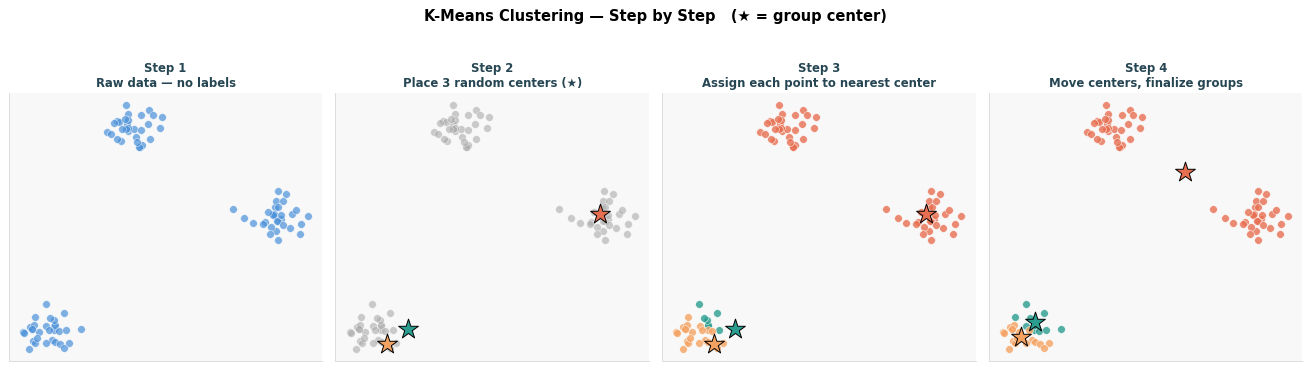
<p><em style="color:#777; font-size:0.9em;">Figure 5 — K-Means repeatedly assigns points to the nearest center and moves the center until groups stabilize.</em></p>
</div>

### Pros & Cons

| Strengths | Weaknesses |
|-----------|------------|
| Simple, fast, and easy to understand | You must decide K (number of groups) in advance |
| Works well when groups are similarly sized | Results can vary depending on where centers start |
| Great for exploring new data | Does not handle oddly shaped groups well |

**Common real-world uses:** Customer segmentation, grouping similar articles or products, image compression.

### How do I choose K?

Use the **Elbow Method**: run K-Means for different values of K and plot how compact
the groups are. The best K is at the "elbow" — where adding more groups stops helping much.

<div align="center" style="margin:14px 0;">
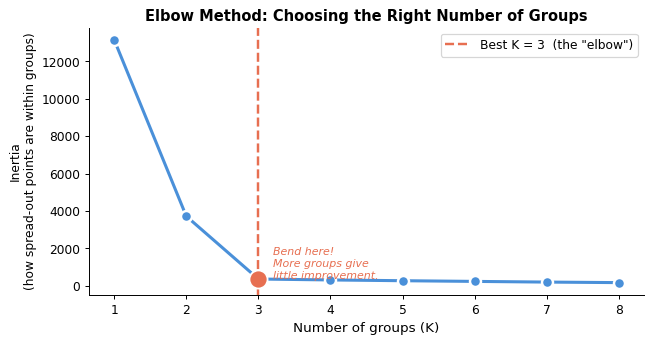
<p><em style="color:#777; font-size:0.9em;">Figure 6 — The curve bends (elbows) at K=3. Adding a 4th group gives almost no improvement.</em></p>
</div>

### Key Parameters — K-Means

| Parameter | What it does | Our value | Effect of changing it |
|-----------|-------------|-----------|----------------------|
| `n_clusters` | How many groups (K) to divide the data into | `3` | Too few = groups are too broad; too many = groups are meaninglessly small. Use the Elbow Method to choose |
| `n_init` | How many times to restart with different random starting centers, keeping the best result | `10` | Higher = more reliable result, but slower. Default is 10, usually fine |
| `random_state` | Fixes starting positions of centers for reproducibility | `42` | Any integer |

> **Why does n_init matter?** K-Means can get "stuck" depending on where the starting centers are placed.
> Running it 10 times and keeping the best result avoids bad luck on the first try.

In [ ]:
# ── Helper: create student study habit data ──────────────────────────────────
def making_data_for_kmeans():
    """
    Returns fake student data with two features:
      - Column 0: hours spent in the library per week (~3 to 21 hrs)
      - Column 1: average test score (%)
    Students naturally fall into 3 groups based on their study habits.
    """
    np.random.seed(42)
    X, _ = make_blobs(
        n_samples=150,   # 150 students in our dataset
        centers=3,       # data is generated around 3 natural cluster centers
        cluster_std=1.0, # how spread out each cluster is (higher = more overlap)
        random_state=42
    )
    # Rescale to realistic values
    X[:, 0] = X[:, 0] * 3 + 12   # convert to library hours: roughly 3 to 21 hrs/week
    X[:, 1] = X[:, 1] * 10 + 75  # convert to test scores: roughly 45% to 105%
    return X

# Call it and cluster students into 3 groups
X_students = making_data_for_kmeans()

kmeans = KMeans(
    n_clusters=3,    # we want to find 3 groups
    n_init=10,       # try 10 different random starting positions, keep the best
    random_state=42  # fixes starting positions for reproducibility
)
group_labels = kmeans.fit_predict(X_students)  # assigns each student to a group (0, 1, or 2)

# Summarize each group (sorted by avg library hours)
order = np.argsort([X_students[group_labels==i, 0].mean() for i in range(3)])
names = ["Light Studiers", "Moderate Studiers", "Heavy Studiers"]

print(f"{'Group':<20} {'Library Hrs/wk':>16} {'Avg Score':>10} {'Count':>8}")
print("-" * 58)
for rank, gi in enumerate(order):
    mask = group_labels == gi
    print(f"{names[rank]:<20} {X_students[mask,0].mean():>16.1f} "
          f"{X_students[mask,1].mean():>9.1f}% {mask.sum():>8}")

---

---
# Part 3: Loss Functions — Measuring How Wrong We Are

## 3.1 How Does a Model Learn?

When we train a model, it adjusts its internal settings until its predictions match
the correct answers as closely as possible. But how does the model know if it is getting better?

It uses a **loss function** — a formula that measures *how wrong* the predictions are.
The lower the loss, the better the model.

Training = repeating this loop until the loss stops improving:

```
1. Make predictions on training data
2. Calculate the loss (how wrong are we?)
3. Adjust the model to reduce the loss
4. Repeat
```

---
## 3.2 Three Common Loss Functions

These are used when predicting a **number** (like delivery time or house price).

Let:  $y$ = the true value,   $\hat{y}$ = the predicted value,   $n$ = number of examples

---

### **MAE** — Mean Absolute Error
$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
Take the average of all errors, ignoring the sign. Every error is treated equally.

---

### **MSE** — Mean Squared Error
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
Square each error before averaging. This means big errors are punished **much** more than small ones.

---

### **RMSE** — Root Mean Squared Error
$$\text{RMSE} = \sqrt{\text{MSE}}$$
Same as MSE, but take the square root to get back to the original units (minutes, dollars, etc.)

---

<div align="center" style="margin:14px 0;">
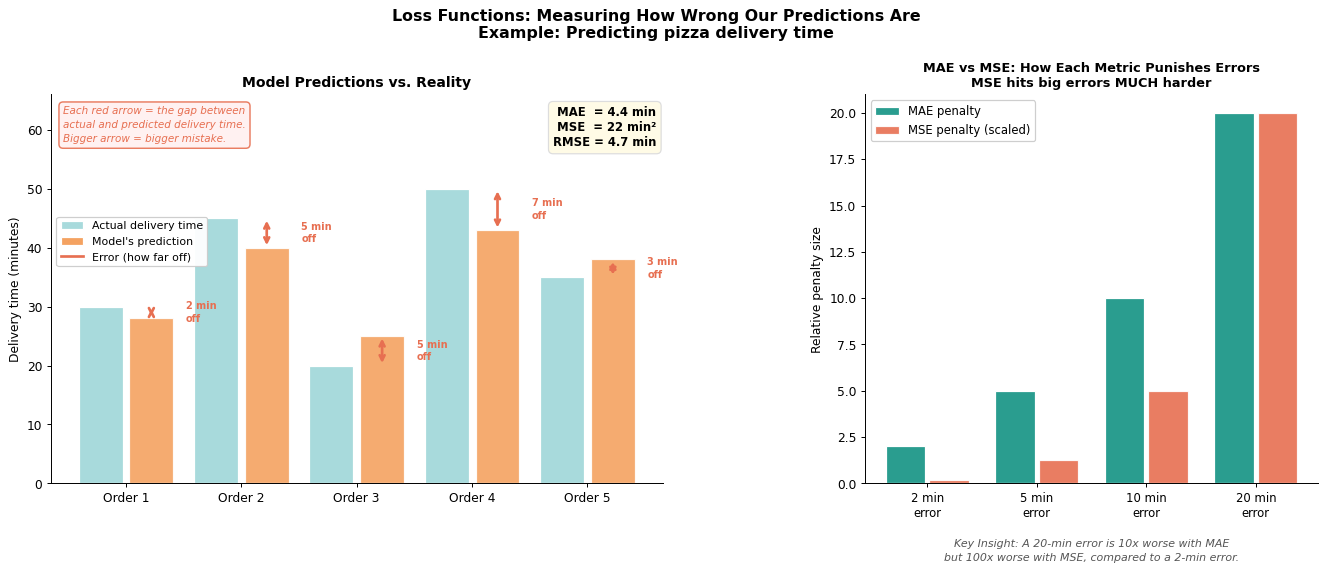
<p><em style="color:#777; font-size:0.9em;">Figure 7 — Left: our model vs. reality on 5 pizza orders. Right: how MAE and MSE penalize large vs. small errors differently.</em></p>
</div>

### At a Glance

| Metric | Penalizes big errors heavily? | Units | Best when... |
|--------|------------------------------|-------|--------------|
| **MAE** | No — all errors equal | Same as data | You want fairness toward all errors; data has outliers |
| **MSE** | Yes — very much so | Squared | Big mistakes are very costly |
| **RMSE** | Yes — very much so | Same as data | You want MSE but need easy-to-interpret results |

---

### Key Parameters — Loss Functions (MAE, MSE, RMSE)

These aren't model parameters — they're **formulas** you choose to measure error. Here's when to use each:

| Metric | Formula (plain English) | Units | Use this when... |
|--------|------------------------|-------|-----------------|
| `MAE` | Average of all absolute errors | Same as data (minutes) | Errors should all count equally; data has outliers you don't want to over-punish |
| `MSE` | Average of all squared errors | Squared (minutes²) | Big mistakes are much more costly than small ones |
| `RMSE` | Square root of MSE | Same as data (minutes) | You want MSE's behavior but need the result in original units for easy reading |

> **Quick intuition:** If your model is 2 min off once and 10 min off once:
> - MAE treats them as: `(2 + 10) / 2 = 6 min` average
> - MSE treats them as: `(4 + 100) / 2 = 52 min²` — the 10-min error dominates!

In [ ]:
# ── Helper: create pizza delivery prediction data ────────────────────────────
def making_data_for_loss_functions():
    """
    Returns two arrays of pizza delivery times (in minutes):
      - true_times:  what actually happened
      - pred_times:  what our model predicted
    5 orders, each with a small error so we can compute MAE, MSE, RMSE.
    """
    true_times = np.array([30, 45, 20, 50, 35])  # actual delivery times
    pred_times = np.array([28, 40, 25, 43, 38])  # model's guesses
    return true_times, pred_times

# Call it and compute all three loss metrics
true_times, pred_times = making_data_for_loss_functions()
errors = true_times - pred_times   # positive = predicted too fast; negative = predicted too slow

print("Order | True | Predicted | Error")
print("-" * 38)
for i,(t,p,e) in enumerate(zip(true_times, pred_times, errors), 1):
    print(f"  {i}   | {t:4} |     {p:4}    | {e:+5} min")

print()
mae  = np.mean(np.abs(errors))    # ignore direction — just how far off on average
mse  = np.mean(errors ** 2)       # squaring makes big errors count A LOT more
rmse = np.sqrt(mse)               # undo the squaring to get back to minutes

print(f"MAE  = {mae:.1f} minutes  <- average absolute error")
print(f"MSE  = {mse:.1f} min2     <- squared units, big errors dominate")
print(f"RMSE = {rmse:.1f} minutes  <- like MSE but back in original units")
print()
print(f"In plain English: our model is typically off by about {rmse:.1f} minutes.")

---

---
# Part 4: Regularization — Preventing Overfitting

## 4.1 The Problem: Overfitting

Imagine studying for an exam by memorizing every practice problem word-for-word.
You ace those exact problems — but fail when the same concept is asked differently.
That is **overfitting**: the model memorizes training examples instead of learning the general pattern.

| Situation | Training Performance | Test Performance |
|-----------|---------------------|-----------------|
| **Underfitting** | Bad | Bad |
| **Good Fit** | Good | Good |
| **Overfitting** | Great | Bad |

<div align="center" style="margin:14px 0;">
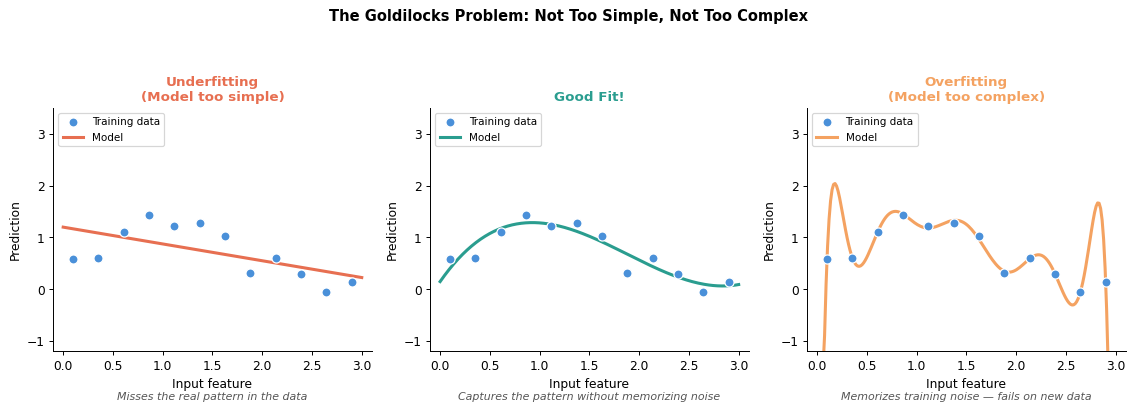
<p><em style="color:#777; font-size:0.9em;">Figure 8 — Underfitting (red) misses the pattern. Overfitting (orange) memorizes every bump. The good fit (green) captures the true shape.</em></p>
</div>

---
## 4.2 Regularization: Adding a Penalty

**Regularization** discourages the model from making its internal weights too large or too numerous,
which prevents overfitting.

$$\text{New Loss} = \text{Original Loss} + \lambda \times \text{Complexity Penalty}$$

$\lambda$ (lambda) controls how strong the penalty is. Larger $\lambda$ = simpler model.

---

### Ridge Regression (L2 Regularization)

**Penalty:** $\lambda \sum w_j^2$ — sum of squared weights

Pushes all weights **toward zero**, but **never exactly to zero**.
Think of it as slowly lowering the volume — quieter but never silent.

### Lasso Regression (L1 Regularization)

**Penalty:** $\lambda \sum |w_j|$ — sum of absolute weights

Can push weights to **exactly zero** — effectively removing irrelevant features entirely.
Think of it as turning off lights in empty rooms — completely off.

---

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Effect on weights | Shrinks toward 0, never exactly 0 | Can set to **exactly 0** |
| Removes irrelevant features? | No | **Yes** |
| Best when | Most features contribute something | Only a few features truly matter |

<div align="center" style="margin:14px 0;">
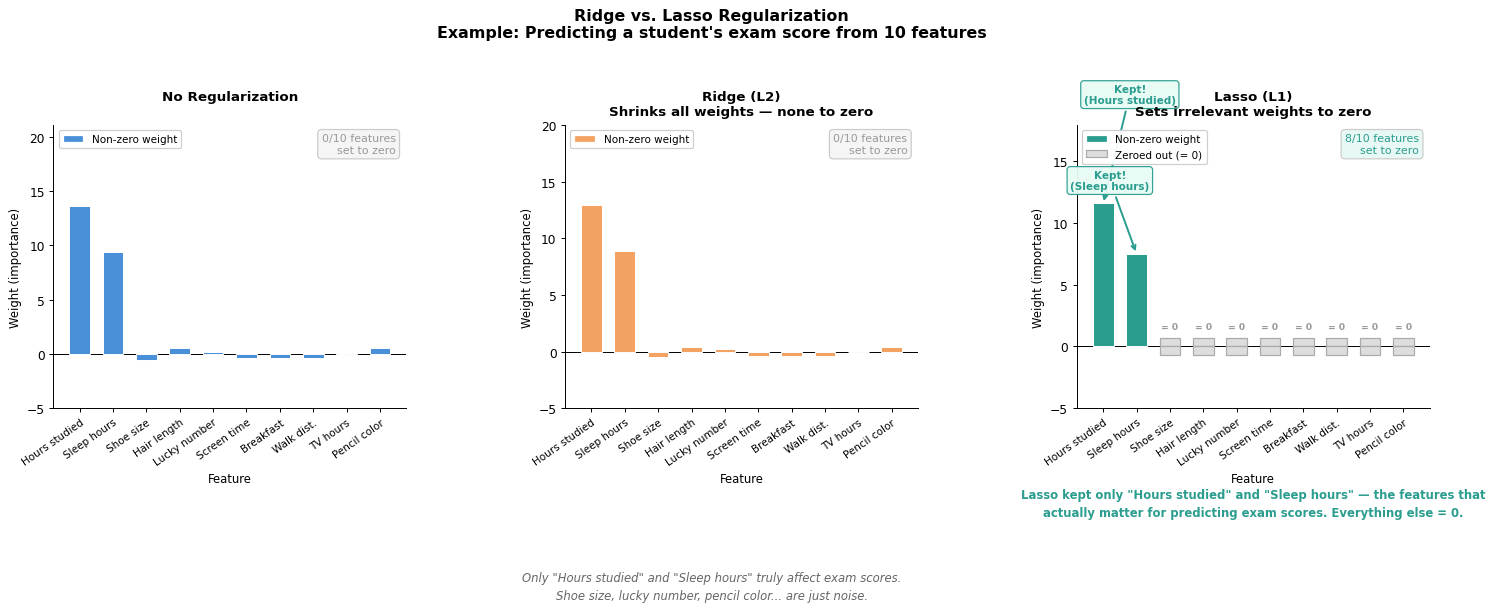
<p><em style="color:#777; font-size:0.9em;">Figure 9 — Plain regression (left) has wild weights. Ridge (middle) shrinks them. Lasso (right) removes irrelevant features entirely (gray bars = zero).</em></p>
</div>

### Key Parameters — Ridge and Lasso

Both Ridge and Lasso add a **penalty term** controlled by one key parameter:

| Parameter | What it does | Ridge value | Lasso value | Effect of changing it |
|-----------|-------------|-------------|-------------|----------------------|
| `alpha` | Strength of the penalty — how hard the model is pushed to keep weights small | `10` | `1.8` | Higher alpha = simpler model, more weights shrunk/zeroed; lower alpha = closer to no regularization |
| `max_iter` | Max number of optimization steps (Lasso only — it's harder to solve) | — | `10000` | Increase if you see a "convergence" warning |

> **Choosing alpha:** There is no single right answer — it depends on your data.
> Common approach: try a range of values (e.g. `0.01, 0.1, 1, 10, 100`) and use cross-validation to pick the best one.
> A higher alpha forces the model to be more conservative — useful when you have many noisy features.

In [ ]:
# ── Helper: create exam score prediction data ────────────────────────────────
def making_data_for_regularization():
    """
    Returns train/test splits for predicting a student's exam score.
    10 features total — but ONLY 'hours studied' and 'sleep hours' truly matter.
    The other 8 (shoe size, lucky number, pencil color...) are pure noise.
    This is perfect for showing how Lasso zeroes out irrelevant features.
    """
    from sklearn.preprocessing import StandardScaler
    np.random.seed(42)
    X = np.random.randn(200, 10)  # 200 students, 10 features each
    # Only the first two features (hours studied, sleep) affect the score
    y = 15*X[:, 0] + 8*X[:, 1] + np.random.randn(200) * 5
    X = StandardScaler().fit_transform(X)  # rescale all features to same range (important for regularization!)
    return train_test_split(X, y, test_size=0.3, random_state=42)

feature_names = [
    'Hours studied', 'Sleep hours', 'Shoe size', 'Hair length',
    'Lucky number',  'Screen time', 'Breakfast', 'Walk dist.',
    'TV hours',      'Pencil color'
]

# Call it and compare regularization methods
X_tr, X_te, y_tr, y_te = making_data_for_regularization()

no_reg = LinearRegression().fit(X_tr, y_tr)  # no penalty — uses all features equally

ridge  = Ridge(
    alpha=10          # moderate penalty: shrinks all weights toward 0, but none reach exactly 0
).fit(X_tr, y_tr)

lasso  = Lasso(
    alpha=1.8,        # penalty strong enough to zero out the 8 noise features
    max_iter=10000    # lasso needs more steps to converge than ridge — increase if you see warnings
).fit(X_tr, y_tr)

print(f"{'Model':<22} {'Features zeroed out':>22} {'Test MAE':>10}")
print("-" * 56)
for name, m in [("No Regularization", no_reg),
                ("Ridge (L2)",        ridge),
                ("Lasso (L1)",        lasso)]:
    n_zero = int(np.sum(np.abs(m.coef_) < 0.05))
    mae_v  = mean_absolute_error(y_te, m.predict(X_te))
    print(f"{name:<22} {n_zero:>22}/10  {mae_v:>9.1f}")

print()
print("Lasso zeroed out noise features like 'shoe size' and 'pencil color',")
print("keeping only 'hours studied' and 'sleep hours' — the ones that actually matter!")

print()
print("Lasso weights by feature:")
for fname, w in zip(feature_names, lasso.coef_):
    status = f"{w:+.2f}" if abs(w) >= 0.05 else "  = 0  (removed)"
    print(f"  {fname:<16} {status}")

---
# Chapter Summary

Well done making it through the chapter! Here is a full recap:

---

### Supervised Learning — Tree Models

| Model | Core Idea | Best For |
|-------|-----------|---------|
| **Decision Tree** | Asks yes/no questions down a tree | Easy explanations, quick baselines |
| **Random Forest** | Many trees vote together | Reliable accuracy, general use |
| **XGBoost** | Each tree corrects previous errors | Maximum accuracy on tabular data |

---

### Unsupervised Learning

| Method | Idea | Common Uses |
|--------|------|-------------|
| **K-Means** | Groups similar points around centers | Customer segments, pattern discovery |

Use the **Elbow Method** to choose the right number of groups (K).

---

### Loss Functions

| Metric | Key Trait | Use When |
|--------|----------|----------|
| **MAE** | All errors treated equally | Data has outliers; fairness matters |
| **MSE** | Big errors penalized heavily | Big mistakes are very costly |
| **RMSE** | Like MSE but in original units | Easiest to interpret in practice |

---

### Regularization

| Method | Effect | Feature Selection? |
|--------|--------|-------------------|
| **Ridge (L2)** | Shrinks all weights toward 0, but **does NOT** equal 0 | No |
| **Lasso (L1)** | Sets irrelevant weights to exactly 0 | **Yes** |

---

### sklearn Quick Reference — What Code to Use

| Model | Task | Output type | Import & Class |
|-------|------|-------------|----------------|
| **Decision Tree** | Classification | Categories (e.g. rain / no rain) | `from sklearn.tree import DecisionTreeClassifier` |
| **Decision Tree** | Regression | Numbers (e.g. price, score) | `from sklearn.tree import DecisionTreeRegressor` |
| **Random Forest** | Classification | Categories | `from sklearn.ensemble import RandomForestClassifier` |
| **Random Forest** | Regression | Numbers | `from sklearn.ensemble import RandomForestRegressor` |
| **XGBoost** | Classification | Categories | `from sklearn.ensemble import GradientBoostingClassifier` |
| **XGBoost** | Regression | Numbers | `from sklearn.ensemble import GradientBoostingRegressor` |
| **K-Means** | Clustering | Group labels | `from sklearn.cluster import KMeans` |
| **Ridge** | Regression | Numbers | `from sklearn.linear_model import Ridge` |
| **Lasso** | Regression | Numbers | `from sklearn.linear_model import Lasso` |

> **Classification vs Regression — how to tell them apart:**
> - *Classification* → the answer is a **category**: "Will it rain? Yes or No", "Is this spam? Yes or No"
> - *Regression* → the answer is a **number**: "How many minutes late?", "What will the price be?"

Here is a minimal template you can copy for any model:

```python
from sklearn.model_selection import train_test_split

# 1. Split your data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Create and train the model  (swap in any class from the table above)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Evaluate
print(f"Accuracy: {model.score(X_test, y_test):.1%}")
```

---

> **The Big Takeaway:** There is no single best model. The right choice depends on your data,
> your goal, and what kinds of errors you can afford to make.
> **Always try multiple approaches and compare!**